In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving car_price_prediction_.csv to car_price_prediction_.csv


In [3]:
df = pd.read_csv('/content/car_price_prediction_.csv')

In [4]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [5]:
df.tail()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5
2499,2500,Toyota,2005,4.6,Diesel,Automatic,80978,Used,16594.14,RAV4


In [6]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(2500, 10)


In [7]:

df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [9]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [10]:
df.isnull().sum()

,0
Car ID,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop("Car ID", axis=1)

df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [13]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 Brand
['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']

 Fuel Type
['Petrol' 'Electric' 'Diesel' 'Hybrid']

 Transmission
['Manual' 'Automatic']

 Condition
['New' 'Used' 'Like New']

 Model
['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'GLA' 'A3' 'X5' 'C-Class' 'E-Class'
 'CR-V' 'Camry' 'Accord' 'GLC' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'RAV4' 'Focus']


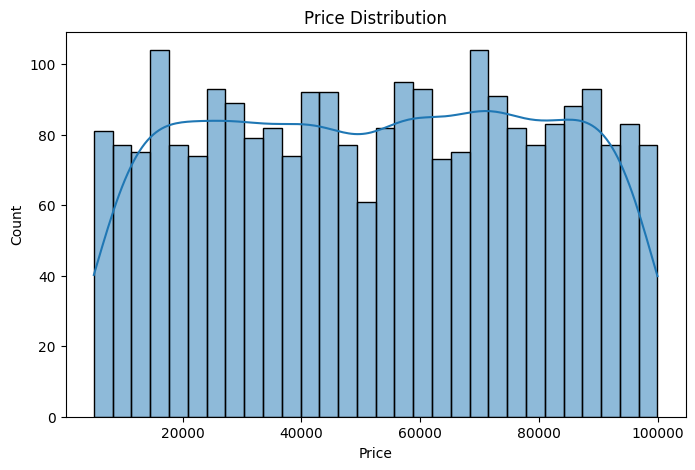

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

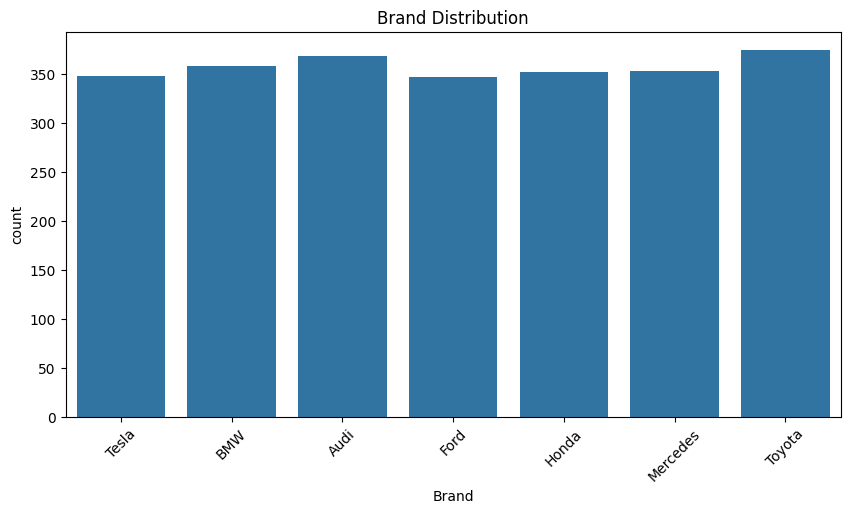

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='Brand', data=df)
plt.title("Brand Distribution")
plt.xticks(rotation=45)
plt.show()

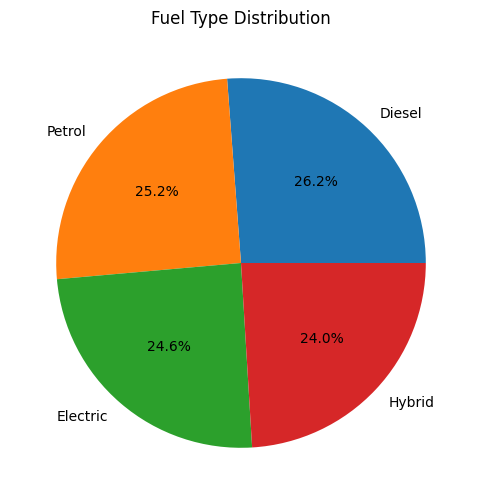

In [16]:
df['Fuel Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Fuel Type Distribution")
plt.ylabel("")
plt.show()

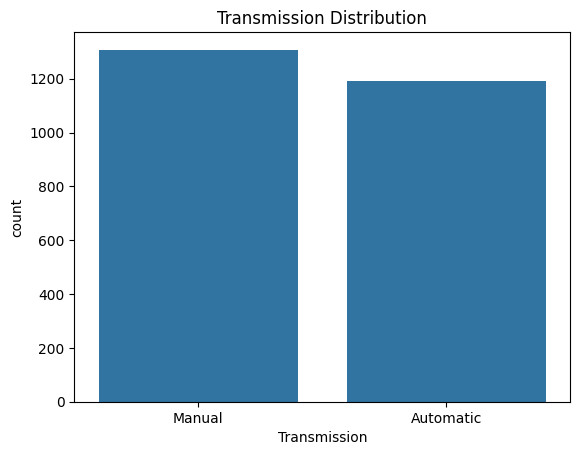

In [17]:
sns.countplot(x='Transmission', data=df)
plt.title("Transmission Distribution")
plt.show()

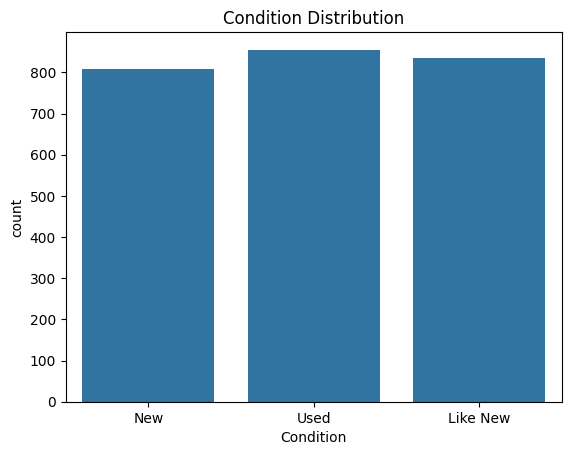

In [18]:
sns.countplot(x='Condition', data=df)
plt.title("Condition Distribution")
plt.show()

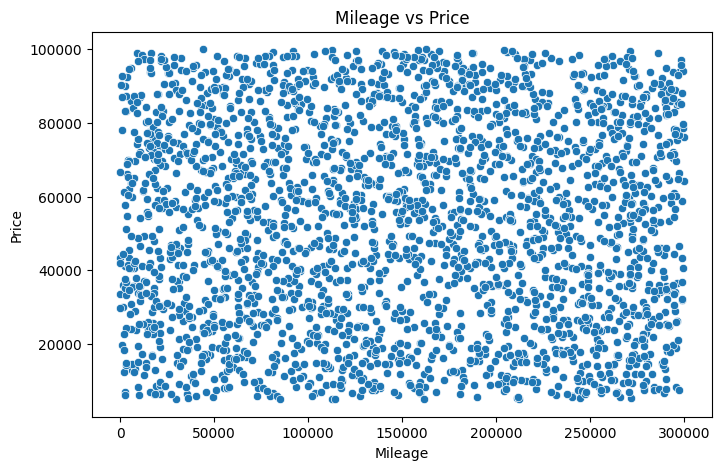

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=df)
plt.title("Mileage vs Price")
plt.show()

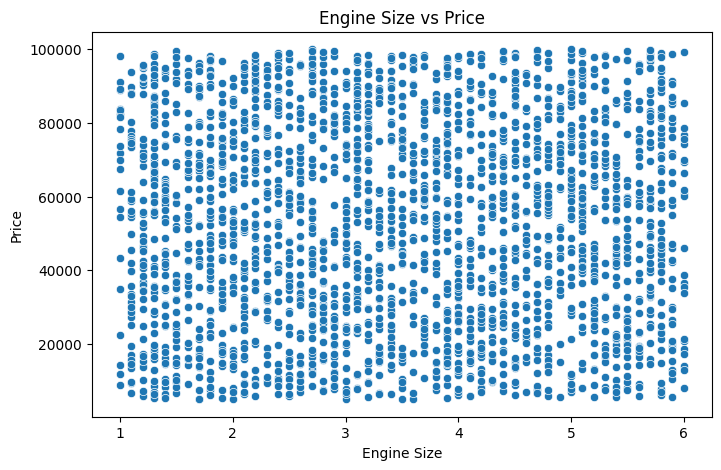

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Engine Size', y='Price', data=df)
plt.title("Engine Size vs Price")
plt.show()

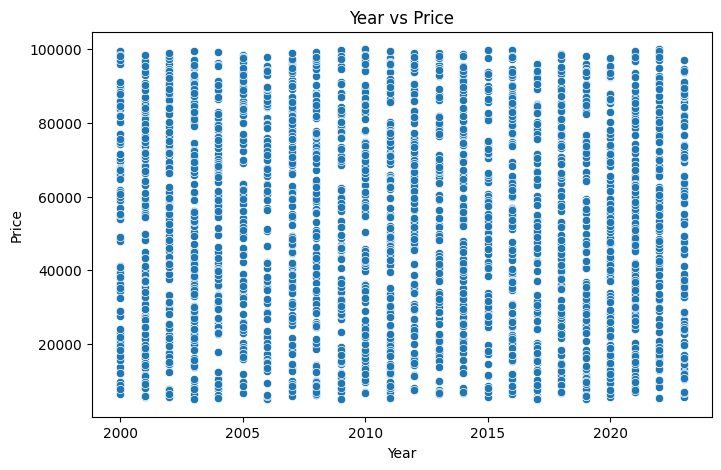

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Year', y='Price', data=df)
plt.title("Year vs Price")
plt.show()

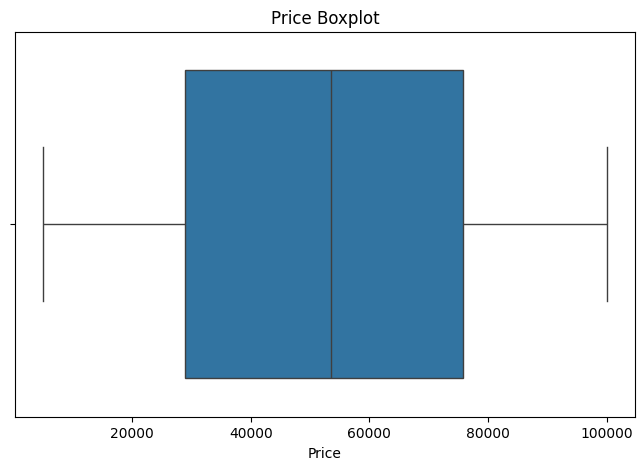

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title("Price Boxplot")
plt.show()

In [23]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,5,2016,2.3,3,1,114832,1,26613.92,19
1,1,2018,4.4,1,1,143190,2,14679.61,1
2,0,2013,4.5,1,1,181601,1,44402.61,3
3,5,2011,4.1,0,0,68682,1,86374.33,20
4,2,2009,2.6,0,1,223009,0,73577.10,21


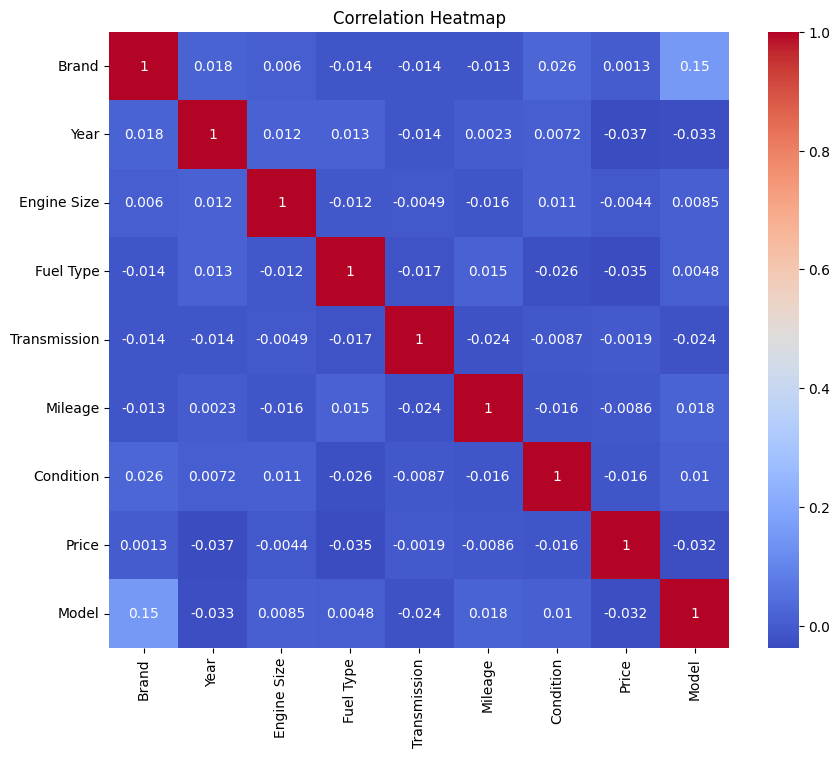

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
X = df.drop("Price", axis=1)

y = df["Price"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(2000, 8)
(500, 8)


In [28]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [29]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 :", r2_lr)

MAE : 23692.564222638546
RMSE : 27550.254691524686
R2 : -0.0019314828693974828


In [30]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [31]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("MAE :", mae_dt)
print("RMSE :", rmse_dt)
print("R2 :", r2_dt)

MAE : 30612.87358
RMSE : 37971.96286461712
R2 : -0.9033246932527201


In [32]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [33]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 :", r2_rf)

MAE : 24202.7420072
RMSE : 28193.953944971934
R2 : -0.0492977922157507


In [34]:
results = pd.DataFrame({
    'Model':['Linear Regression',
             'Decision Tree',
             'Random Forest'],

    'MAE':[mae_lr,
           mae_dt,
           mae_rf],

    'RMSE':[rmse_lr,
            rmse_dt,
            rmse_rf],

    'R2 Score':[r2_lr,
                r2_dt,
                r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,23692.564223,27550.254692,-0.001931
1,Decision Tree,30612.873580,37971.962865,-0.903325
2,Random Forest,24202.742007,28193.953945,-0.049298


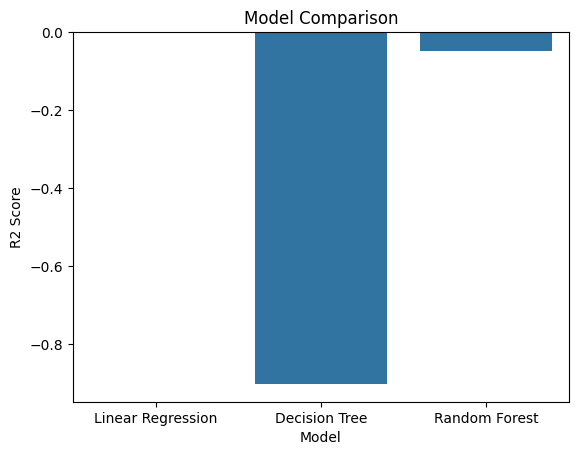

In [35]:
sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")
plt.show()

In [36]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
5,Mileage,0.284685
2,Engine Size,0.200793
1,Year,0.155865
7,Model,0.144924
0,Brand,0.066611
3,Fuel Type,0.064925
6,Condition,0.051590
4,Transmission,0.030608


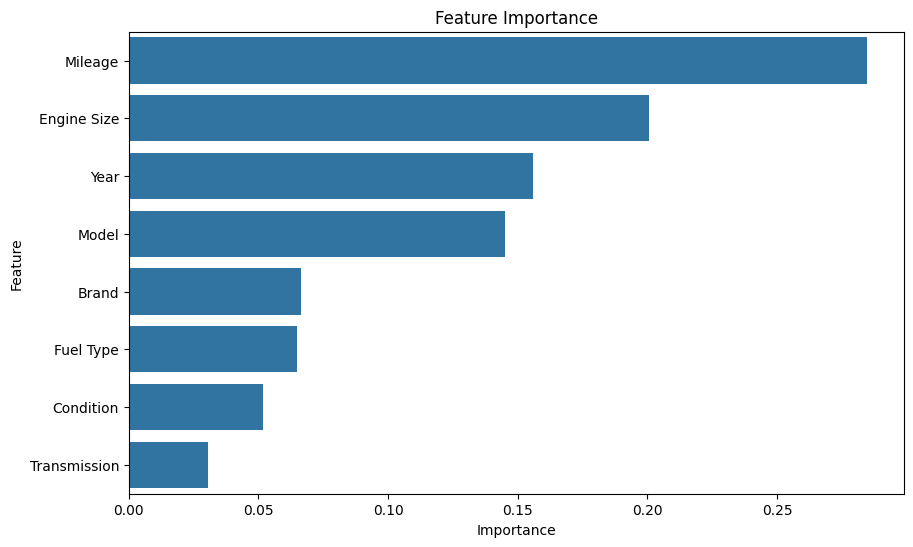

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

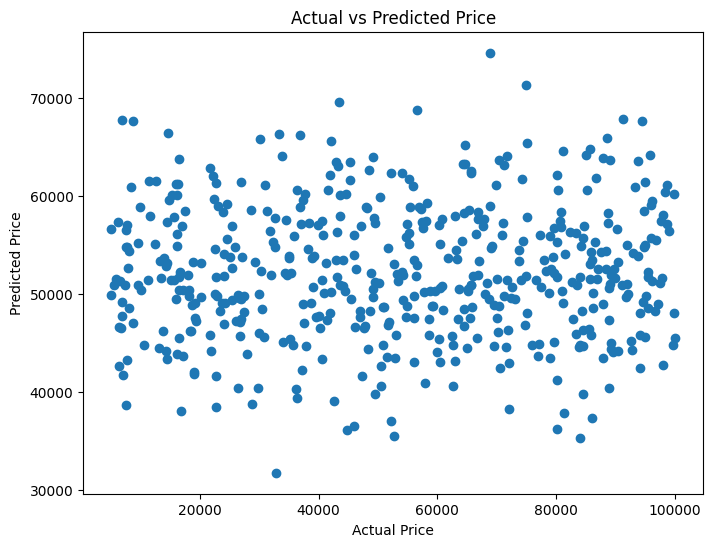

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [39]:
import joblib

joblib.dump(
    rf,
    'car_price_model.pkl'
)

print("Model Saved Successfully")

Model Saved Successfully
